In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

Problem 1 to 2:
Dataset link: https://rb.gy/gsmddu

Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations. Then, you can customize it as your wish.

Problem-1: Make a subplots which have 2 plots.
For the first chart, draw a scatter plot "Monitored Cap.(MW)" vs "Total Cap. Under Maintenance (MW)" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
For the second chart, draw a scatter plot "Monitored Cap. (MW)" vs "Actual(MU)" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.

In [5]:
df=pd.read_csv('PowerGeneration - PowerGeneration.csv')

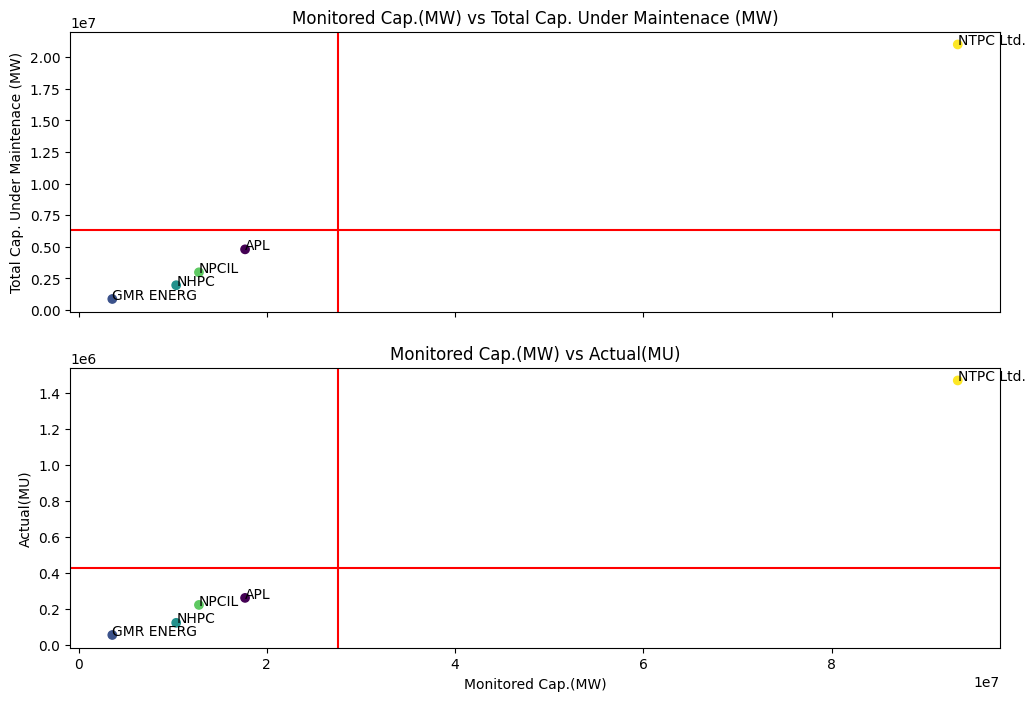

In [81]:
top5=df['Power Station'].value_counts().head(5)

df=df[df['Power Station'].isin(top5.index)]
new_df=df.groupby('Power Station')[['Monitored Cap.(MW)','Total Cap. Under Maintenace (MW)']].sum().reset_index()

fig, ax =plt.subplots(nrows=2,ncols=1,sharex=True,figsize=(12,8))

ax[0].scatter(new_df['Monitored Cap.(MW)'],new_df['Total Cap. Under Maintenace (MW)'],c=new_df.index)
ax[0].set_title('Monitored Cap.(MW) vs Total Cap. Under Maintenace (MW)')
ax[0].set_ylabel('Total Cap. Under Maintenace (MW)')
ax[0].axhline(new_df['Total Cap. Under Maintenace (MW)'].mean(),color='red')
ax[0].axvline(new_df['Monitored Cap.(MW)'].mean(),color='red')

for i in range(new_df.shape[0]):
    ax[0].text(new_df['Monitored Cap.(MW)'].values[i],new_df['Total Cap. Under Maintenace (MW)'].values[i],new_df['Power Station'].values[i])

new_df2=df.groupby('Power Station')[['Monitored Cap.(MW)','Actual(MU)']].sum().reset_index()
ax[1].scatter(new_df2['Monitored Cap.(MW)'],new_df2['Actual(MU)'],c=new_df2.index)
ax[1].set_title('Monitored Cap.(MW) vs Actual(MU)')
ax[1].set_xlabel('Monitored Cap.(MW)')
ax[1].set_ylabel('Actual(MU)')
ax[1].axhline(new_df2['Actual(MU)'].mean(),color='red')
ax[1].axvline(new_df2['Monitored Cap.(MW)'].mean(),color='red')

for i in range(new_df2.shape[0]):
   ax[1].text(new_df2['Monitored Cap.(MW)'].values[i],new_df2['Actual(MU)'].values[i],new_df2['Power Station'].values[i])





Problem-2: Draw a 3D Scatter plot between "Monitored Cap.(MW)", "Total Cap. Under Maintenace (MW)" and "Forced Maintanence(MW)"

Text(0.5, 0, 'Forced Maintanence(MW)')

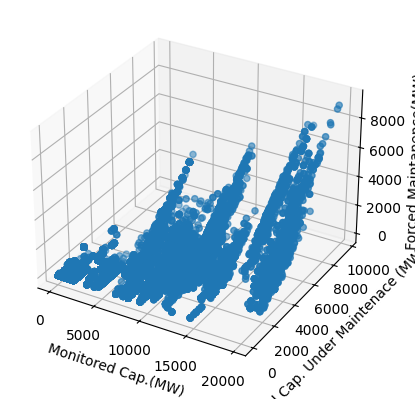

In [ ]:
fig=plt.figure()

ax=plt.subplot(projection='3d')
ax.scatter3D(df['Monitored Cap.(MW)'],df['Total Cap. Under Maintenace (MW)'],df['Forced Maintanence(MW)'])

ax.set_xlabel('Monitored Cap.(MW)')
ax.set_ylabel('Total Cap. Under Maintenace (MW)')
ax.set_zlabel('Forced Maintanence(MW)')

Problem-3: Make a 3D Surface plot of this below mathematical equation.
z=|x|−|y|

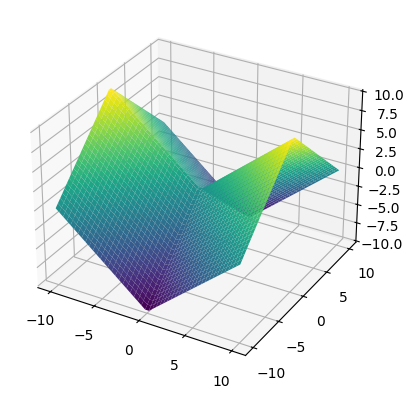

In [92]:
x=np.linspace(-10,10,50)
y=np.linspace(-10,10,50)
xx,yy=np.meshgrid(x,y)
z=np.abs(xx)-np.abs(yy)

fig=plt.figure()
ax=plt.subplot(projection='3d')
ax.plot_surface(xx,yy,z,cmap='viridis')

Problem-4: Draw the 3D Contour plot of this below equation:
z=|x|−|y|

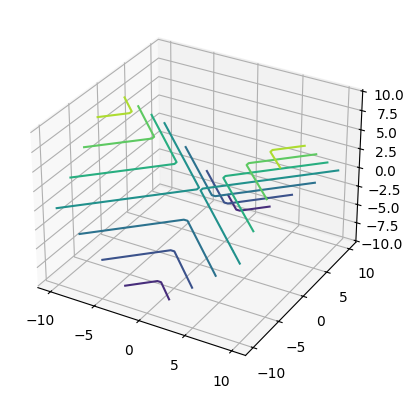

In [100]:
x=np.linspace(-10,10,50)
y=np.linspace(-10,10,50)
xx,yy=np.meshgrid(x,y)
z=np.abs(xx)-np.abs(yy)

fig=plt.figure()
ax=plt.subplot(projection='3d')
ax.contour(xx,yy,z,cmap='viridis')

Problem-5: Draw a second type of Countour plot of the below equation:
z=|x|−|y|

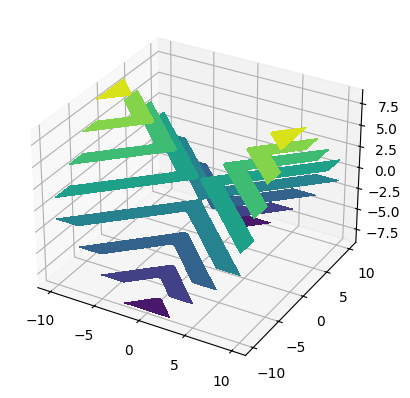

In [101]:
x=np.linspace(-10,10,50)
y=np.linspace(-10,10,50)
xx,yy=np.meshgrid(x,y)
z=np.abs(xx)-np.abs(yy)

fig=plt.figure()
ax=plt.subplot(projection='3d')
ax.contourf(xx,yy,z,cmap='viridis')

Problem 6-7
Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link

Description of Dataset:

Date: It gives the date of which stocks details are given.
Symbol: Name of stock
Open: It gives the opening price of stock on that date.
High: It gives the highest price to which the stock ascened on that day.
Low: It gives the highest price to which the stock plummeted on that day.
Close: It gives the closing price of stock on that date.
Volume: It gives the amount of stock traded on that date.
VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.

Turnover:

Problem-6 Use Pandas plot functions

Line plot of closing value of top 5 Stocks in Year 2020.
Take top 5 stocks based on total turnover in Year 2020

In [104]:
df1=pd.read_csv('nifty-50 - nifty-50.csv')

In [117]:
df1['Date']=pd.to_datetime(df1['Date'])

In [119]:
df1['Year']=df1['Date'].dt.year

<Axes: title={'center': '2020 Daily Closing Prices of Top 5 Stocks by Turnover'}, xlabel='Date'>

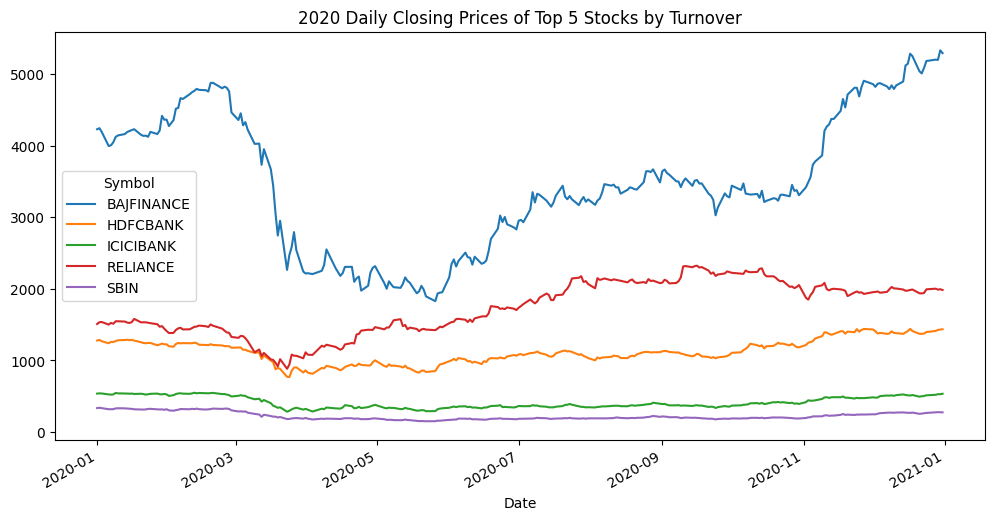

In [150]:
df_2020=df1[df1['Year']==2020]
top5_stocks=df_2020.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False).head(5).index

final_df=df_2020[df_2020['Symbol'].isin(top5_stocks)]
final_df.pivot_table(index='Date',columns='Symbol',values='Close').plot(kind='line',figsize=(12, 6), 
    title='2020 Daily Closing Prices of Top 5 Stocks by Turnover')


Problem-7 Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
Color on Symbol Column

<Axes: title={'center': 'Close price vs Volume'}, xlabel='Close', ylabel='Volume'>

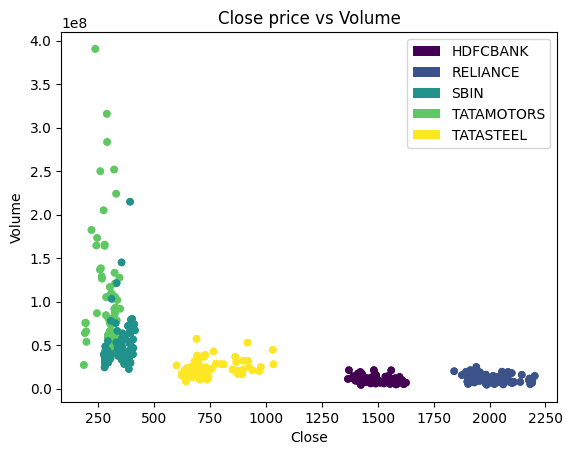

In [165]:
df_2021=df1[df1['Year']==2021]
top5_21=df_2021.groupby('Symbol')['Turnover'].sum().sort_values(ascending=False).head(5).index
df_2021[df_2021['Symbol'].isin(top5_21)].plot(kind='scatter',x='Close',y='Volume',c='Symbol',title='Close price vs Volume')

Problem-8: Create a 3-D Scatter Plot using time,x,y on below synthetic data. and give color gradiant on z
Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})

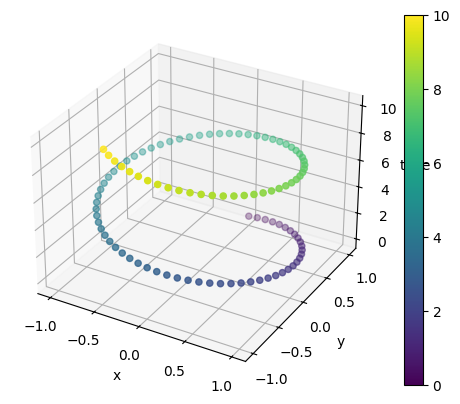

In [174]:
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
fig=plt.figure()
ax=plt.subplot(projection='3d')
p=ax.scatter3D(data['x'],data['y'],data['time'],c=data['z'])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('time')
fig.colorbar(p)

Problem 9: Create a surface plot and the 2 types of the contour plots of the below equation.
z=sin(x2+y2)**0.5

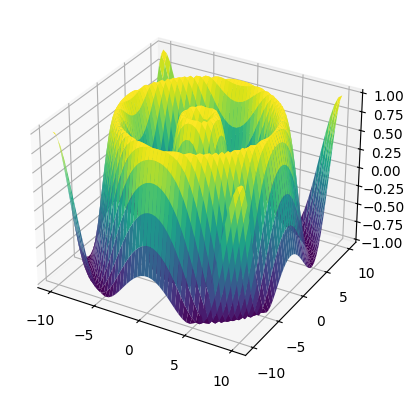

In [178]:
x=np.linspace(-10,10,50)
y=np.linspace(-10,10,50)

xx,yy=np.meshgrid(x,y)

z=np.sin(np.sqrt(xx**2+yy**2))

fig=plt.figure()
ax=plt.subplot(projection='3d')
ax.plot_surface(xx,yy,z,cmap='viridis')


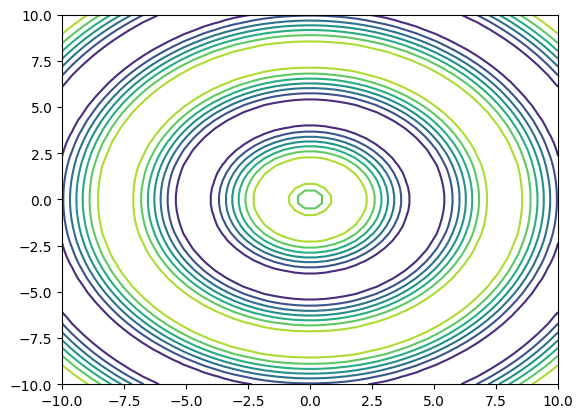

In [179]:
fig=plt.figure()
ax=plt.subplot()
ax.contour(xx,yy,z,cmap='viridis')

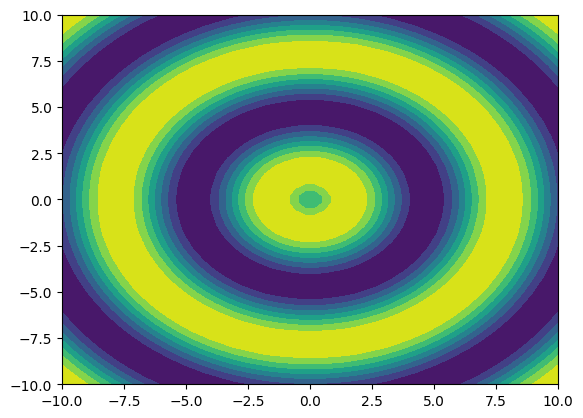

In [180]:
fig=plt.figure()
ax=plt.subplot()
ax.contourf(xx,yy,z,cmap='viridis')

Problem 10: Create a surface plot and the 2 types of the contour plots of the below equation.
z=tan(log2(x2+y2))

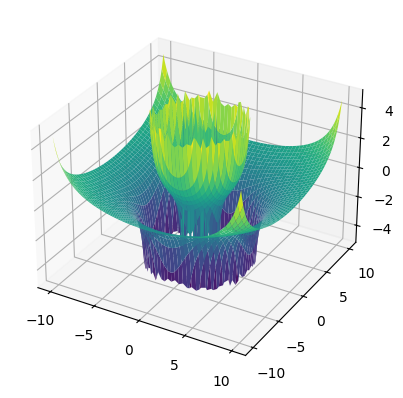

In [191]:
x=np.linspace(-10,10,300)
y=np.linspace(-10,10,300)

xx,yy=np.meshgrid(x,y)

z=np.tan(np.log2(xx**2+yy**2))
# z=np.clip(z,-5,5)
z[(z > 5) | (z < -5)] = np.nan
fig=plt.figure()
ax=plt.subplot(projection='3d')
ax.plot_surface(xx,yy,z,cmap='viridis')

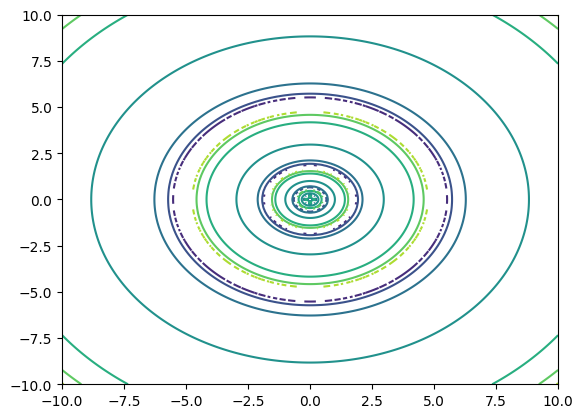

In [192]:
fig=plt.figure()
ax=plt.subplot()
ax.contour(xx,yy,z,cmap='viridis')

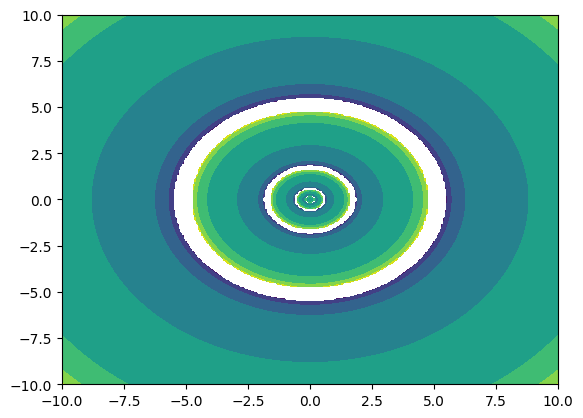

In [193]:
fig=plt.figure()
ax=plt.subplot()
ax.contourf(xx,yy,z,cmap='viridis')